In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
data = pd.read_csv('Data/Mall_Customers.csv', index_col=0)
X = data.iloc[:,[2,3]].values

Text(0, 0.5, 'Euclidean distances')

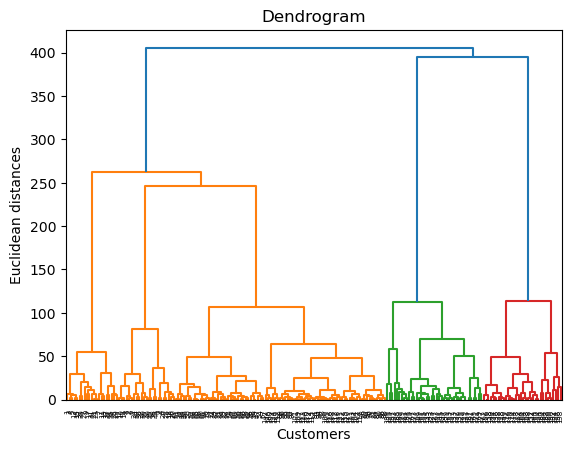

In [5]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')

In [7]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

AttributeError: 'AgglomerativeClustering' object has no attribute 'cluster_centers_'

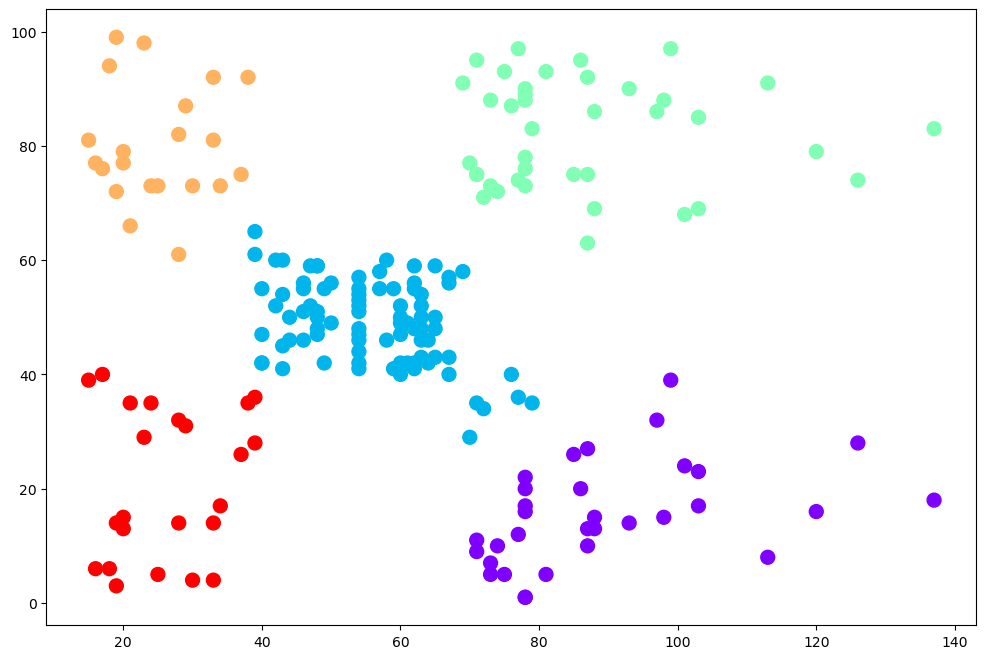

In [8]:
plt.figure(figsize=(12,8))

plt.scatter(X[:,0], X[:,1], c=y_hc, s=100, cmap='rainbow')

centers = hc.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], s=200, c='black', marker='x')

for i, center in enumerate(centers):
    plt.text(center[0], center[1], f'Cluster {i}', fontsize=12, ha='center', )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()